# Phase 2b — Open exploration: a gentle quench and thermalisation

**CERN QTI Hackathon — Quantum twin of TmMgGaO₄**

Per the challenge brief's stretch ideas, we implement **(c) a gentle
quench measuring thermalisation of a local correlator** — the
lowest-effort, most instructive on-ramp to the classically-hard
post-quench regime studied in Fig. 4 of Leclerc et al. and in the two
companion classical-frontier papers (Vovrosh et al., arXiv:2511.19340,
arXiv:2511.20388).

**Protocol** (mirrors Ext. Dat. Fig. 4b): adiabatically prepare the
system near the paramagnetic product state $|{\uparrow}\dots{\uparrow}\rangle$ at a large
$\Delta_z/J_1$, then abruptly (square-pulse) quench $\Delta_z/J_1$ to a value closer
to (or inside) the 1/3-ordered phase, and hold. We track the
nearest-neighbour correlator

$$
C_1^{zz}(t) = \frac{1}{N_b'}\sum_{\langle i,j\rangle \in \text{bulk}} \langle \hat\sigma^z_i(t)\hat\sigma^z_j(t)\rangle
$$

exactly as defined in the paper's post-quench section.

**What makes this a complete deliverable rather than a demo:** the
paper compares its long-time QPU/MPS dynamics against a **thermal
ensemble** at an effective temperature fixed by energy conservation
(their Eq. 8). Building a full QMC-SSE sampler for that is out of scope
for a hackathon — but at this system size ($N=9$) we can do something
better: solve for the exact thermal ensemble via **full diagonalization**
of $\hat H_{QPU}$, with zero stochastic error, and compare directly.


In [1]:
import time
from dataclasses import dataclass
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

from pulser import Register, Sequence, Pulse
from pulser.waveforms import RampWaveform, ConstantWaveform, CompositeWaveform
from pulser.devices import VirtualDevice
from pulser.channels import Rydberg

np.set_printoptions(precision=3, suppress=True)

# Standalone physics helpers for this notebook.


# ---------------------------------------------------------------------------
# 1. Device construction
# ---------------------------------------------------------------------------

def build_device(rydberg_level: int = 75, min_atom_distance: float = 4.0) -> VirtualDevice:
    """Build a VirtualDevice matching one of the paper's Orion Beta QPUs.

    Pasqal's Orion Beta devices used in the paper:
        FM1 (France):     |75 S_1/2, m_J=1/2>   -- used for most data
        FM2/FC1:           |60 S_1/2, m_J=1/2>

    Passing `rydberg_level=75` reproduces C6/(2*pi*hbar) ~= 1949 GHz.um^6,
    matching the value quoted in the paper's Methods for FM1.

    We use a VirtualDevice (no hardware calibration limits on Rabi
    frequency, detuning range or atom number) since this challenge is
    emulation-only and we want to match the *physical* Hamiltonian of the
    paper exactly, not a specific hardware guardrail.
    """
    return VirtualDevice(
        name=f"orion_beta_like_n{rydberg_level}",
        dimensions=2,
        rydberg_level=rydberg_level,
        min_atom_distance=min_atom_distance,
        # Global Rydberg channel with no amplitude/detuning caps -- see docstring above.
        channel_objects=(Rydberg.Global(max_abs_detuning=None, max_amp=None),),
    )


def j1_from_device(device: VirtualDevice, r1: float) -> float:
    """hbar*J1 (rad/us) = C6 / (4 * r1^6), Eq. 4 of Leclerc et al."""
    return device.interaction_coeff / (4.0 * r1**6)


# ---------------------------------------------------------------------------
# 2. Registers
# ---------------------------------------------------------------------------

def square_register(rows: int, cols: int, spacing: float, prefix: str = "q") -> Register:
    """Plain square lattice, for Phase 1 (Scholl et al. AFM warm-up)."""
    return Register.rectangle(rows, cols, spacing=spacing, prefix=prefix)


def triangular_rhombus_register(
    l_bulk: int, r1: float, buffer_rows: int = 2, prefix: str = "q"
) -> tuple[Register, np.ndarray]:
    """Triangular-lattice rhombus register, following the paper's Ext. Dat.
    Fig. 3 / Methods prescription.

    The paper arranges atoms on an N = L x L rhombus, with L a multiple of
    3 plus `buffer_rows` extra rows on each side of the bulk so that
    boundary effects don't contaminate bulk observables (L = 7, 10, 13, 16
    for bulk sizes 3, 6, 9, 12).

    Parameters
    ----------
    l_bulk : int
        Linear size of the bulk region of interest. Must be a multiple of
        3 for commensurability with the 1/3-ordered phase.
    r1 : float
        Nearest-neighbour spacing (um).
    buffer_rows : int
        Extra rows of atoms added on *each* side to reduce edge effects
        (paper default: 2).

    Returns
    -------
    register : pulser.Register
    is_bulk : np.ndarray[bool]
        Boolean mask (same order as register.qubits) marking which atoms
        belong to the (L_bulk x L_bulk) bulk region used for observables,
        as opposed to the boundary buffer.
    """
    if l_bulk % 3 != 0:
        raise ValueError(
            f"l_bulk={l_bulk} must be a multiple of 3 for commensurability "
            "with the 1/3-filling order (see Leclerc et al., Methods)."
        )
    L = l_bulk + 2 * buffer_rows  # total side length including the buffer on both sides

    coords = []
    is_bulk = []
    lo, hi = buffer_rows, buffer_rows + l_bulk  # bulk index range [lo, hi), same on rows and cols
    for row in range(L):
        for col in range(L):
            # Triangular-lattice basis vectors: each row is shifted by half a
            # lattice spacing along x and by (sqrt(3)/2)*r1 along y, so that
            # every atom has 6 nearest neighbours at distance r1 in the bulk.
            x = col * r1 + row * (r1 / 2.0)
            y = row * r1 * np.sqrt(3) / 2.0
            coords.append((x, y))
            is_bulk.append(lo <= row < hi and lo <= col < hi)
    coords = np.array(coords)
    coords -= coords.mean(axis=0)  # centre the register on the origin (cosmetic, for register.draw())
    reg = Register.from_coordinates(coords, prefix=prefix)
    return reg, np.array(is_bulk, dtype=bool)


def nearest_neighbour_bonds(register: Register, r1: float, tol: float = 0.15):
    """Return list of (i, j) qubit-index pairs at distance ~r1 (bulk NN bonds)."""
    names = list(register.qubits.keys())
    coords = np.array([register.qubits[n] for n in names], dtype=float)
    bonds = []
    n = len(names)
    for i in range(n):
        for j in range(i + 1, n):
            d = np.linalg.norm(coords[i] - coords[j])
            if abs(d - r1) < tol * r1:  # within `tol` fractional tolerance of the lattice spacing
                bonds.append((i, j))
    return bonds


# ---------------------------------------------------------------------------
# 3. Material <-> QPU parameter mapping (Eq. 4)
# ---------------------------------------------------------------------------

@dataclass
class MaterialParams:
    """TmMgGaO4 microscopic model parameters, from Leclerc et al. (citing
    Li et al. PRX 10, 011007 (2020) and H. Li et al. Nat. Commun. 11, 1111
    (2020) for the original characterisation)."""

    J2_over_J1: float = 0.05          # next-nearest-neighbour coupling
    Delta_x_over_J1: float = 1.08     # intrinsic transverse (crystal) field
    delta_z_per_field: float = 1.543  # Delta_z/J1 per Tesla of mu0*H


MATERIAL = MaterialParams()


def delta_U_bulk(J1: float, n_nn: int = 6) -> float:
    """Bulk site-averaged interaction sum delta_U = (1/2) sum_j U_1j,
    dominated by the `n_nn` nearest neighbours (6 on a triangular
    lattice): delta_U ~= (n_nn/2) * U_1 = 2 * n_nn * J1 (since U_1 = 4*J1).
    """
    return (n_nn / 2.0) * (4.0 * J1)


def qpu_controls_from_material(
    Delta_x_over_J1: float, Delta_z_over_J1: float, J1: float
) -> tuple[float, float]:
    """Material (Delta_x/J1, Delta_z/J1) -> QPU controls (Omega, delta), rad/us.

    Inverting Eq. 4:
        Delta_x = Omega / 2                => Omega = 2 * Delta_x
        Delta_z = (delta_U - delta) / 2    => delta = delta_U - 2*Delta_z
    """
    Omega = 2.0 * Delta_x_over_J1 * J1
    dU = delta_U_bulk(J1)
    delta = dU - 2.0 * Delta_z_over_J1 * J1
    return Omega, delta


def material_from_qpu_controls(Omega: float, delta: float, J1: float) -> tuple[float, float]:
    """Inverse of the above: QPU controls -> (Delta_x/J1, Delta_z/J1)."""
    Delta_x_over_J1 = (Omega / 2.0) / J1
    dU = delta_U_bulk(J1)
    Delta_z_over_J1 = (dU - delta) / (2.0 * J1)
    return Delta_x_over_J1, Delta_z_over_J1


def mu0H_from_Delta_z(Delta_z_over_J1: float, params: MaterialParams = MATERIAL) -> float:
    """Convert Delta_z/J1 to the physical applied field mu0*H (Tesla),
    using the paper's quoted Delta_z/J1 ~= 1.543 * mu0*H(T)."""
    return Delta_z_over_J1 / params.delta_z_per_field


# ---------------------------------------------------------------------------
# 4. Analytic classical reference (zero transverse field, Delta_x -> 0)
# ---------------------------------------------------------------------------

def classical_Mz(Delta_z_over_J1: np.ndarray, J2_over_J1: float = MATERIAL.J2_over_J1):
    """Classical (Delta_x = 0) magnetisation, from the energy comparison in
    the main text: E_up...up/N = 3*J1 - Delta_z + O(J2), Mz=1, versus
    E_1/3/N = -J1 - Delta_z/3 + O(J2), Mz=1/3. The crossover sits at
    Delta_z/J1 ~= 6 (quoted in the text for J2 ~ 0.05*J1). This is a sharp
    step in the strict classical limit -- useful as a sanity-check
    reference curve, *not* a fit to data.
    """
    Delta_z_over_J1 = np.asarray(Delta_z_over_J1, dtype=float)
    Dz_c = 6.0  # crossover quoted in the paper for J2/J1 ~ 0.05
    return np.where(Delta_z_over_J1 < Dz_c, 1.0 / 3.0, 1.0)


# ---------------------------------------------------------------------------
# 5. Pulse sequence builders
# ---------------------------------------------------------------------------

def afm_prep_sequence(
    register: Register,
    device: VirtualDevice,
    Omega_max: float,
    delta_start: float,
    delta_end: float,
    t_rise: float,
    t_sweep: float,
    t_fall: float,
) -> Sequence:
    """Phase-1 style quasi-adiabatic AFM-preparation sequence (Scholl et
    al. 2021 protocol): ramp Omega up while sweeping delta from large
    negative to positive/zero, then ramp Omega back down to freeze the
    z-basis populations before readout.

    Timing mirrors Ext. Dat. Fig. 4a of Leclerc et al.: Omega ramps up
    over `t_rise`, both pulses run together for `t_sweep`, Omega ramps
    down over `t_fall` while delta keeps sweeping to `delta_end`.
    """
    seq = Sequence(register, device)
    seq.declare_channel("ryd", "rydberg_global")

    # Rabi frequency: ramp up, hold, ramp down (freezes populations at the end)
    amp = CompositeWaveform(
        RampWaveform(t_rise, 0.0, Omega_max),
        ConstantWaveform(t_sweep, Omega_max),
        RampWaveform(t_fall, Omega_max, 0.0),
    )
    # Detuning: one continuous ramp across the whole pulse duration
    det = RampWaveform(t_rise + t_sweep + t_fall, delta_start, delta_end)
    seq.add(Pulse(amp, det, 0.0), "ryd")
    return seq


def quasi_adiabatic_material_sweep(
    register: Register,
    device: VirtualDevice,
    J1: float,
    Omega_max_over_J1: float,
    Delta_z_start_over_J1: float,
    Delta_z_end_over_J1: float,
    t_rise: float,
    t_sweep: float,
    t_fall: float,
) -> Sequence:
    """Phase-2a sequence: single continuous quasi-adiabatic sweep across
    the material's antiferromagnetic quantum phase transition, built
    directly in *material* units and converted to QPU controls via the
    Eq. 4 mapping. Sampling <Mz(t)> along this one sweep (and converting
    t -> Delta_z(t)/J1 via the mapping) reproduces a full magnetisation
    curve like Fig. 1e / Ext. Dat. Fig. 4a, in a single simulation.
    """
    Omega_max = Omega_max_over_J1 * J1
    # Convert the material's start/end longitudinal fields to QPU detunings
    # (Delta_x is fixed at 0 here -- it only enters through Omega_max, set below).
    _, delta_start = qpu_controls_from_material(0.0, Delta_z_start_over_J1, J1)
    _, delta_end = qpu_controls_from_material(0.0, Delta_z_end_over_J1, J1)

    seq = Sequence(register, device)
    seq.declare_channel("ryd", "rydberg_global")
    amp = CompositeWaveform(
        RampWaveform(t_rise, 0.0, Omega_max),
        ConstantWaveform(t_sweep, Omega_max),
        RampWaveform(t_fall, Omega_max, 0.0),
    )
    det = RampWaveform(t_rise + t_sweep + t_fall, delta_start, delta_end)
    seq.add(Pulse(amp, det, 0.0), "ryd")
    return seq


def gentle_quench_sequence(
    register: Register,
    device: VirtualDevice,
    J1: float,
    Omega_max_over_J1: float,
    Delta_z_prep_over_J1: float,
    Delta_z_quench_over_J1: float,
    t_prep_rise: float,
    t_prep_sweep: float,
    t_hold: float,
) -> Sequence:
    """Phase-2b sequence: adiabatically prepare the ground state at
    Delta_z_prep/J1 (paramagnetic side, following the paper's post-quench
    protocol which starts from |up...up>), then abruptly (square-pulse)
    switch the longitudinal field to Delta_z_quench/J1 and hold, so the
    resulting unitary evolution can be probed for thermalisation of local
    observables (cf. Fig. 4 of Leclerc et al.).
    """
    Omega_max = Omega_max_over_J1 * J1
    _, delta_prep = qpu_controls_from_material(0.0, Delta_z_prep_over_J1, J1)
    _, delta_quench = qpu_controls_from_material(0.0, Delta_z_quench_over_J1, J1)

    seq = Sequence(register, device)
    seq.declare_channel("ryd", "rydberg_global")

    # Preparation: bring the system close to |g...g> = |up...up> ground state
    # of a strongly paramagnetic point, then quench.
    amp_prep = CompositeWaveform(
        RampWaveform(t_prep_rise, 0.0, Omega_max),
        ConstantWaveform(t_prep_sweep, Omega_max),
    )
    # Detuning held constant (start == end) during the prep phase -- Omega
    # ramping up is what turns the interaction on, not a field sweep here.
    det_prep = RampWaveform(t_prep_rise + t_prep_sweep, delta_prep, delta_prep)
    seq.add(Pulse(amp_prep, det_prep, 0.0), "ryd")

    # Square-pulse quench: instantaneous change of the longitudinal field,
    # amplitude held constant (post-quench Hamiltonian sampled at fixed
    # Omega, delta -- as in Ext. Dat. Fig. 4b).
    seq.add(
        Pulse(ConstantWaveform(t_hold, Omega_max), ConstantWaveform(t_hold, delta_quench), 0.0),
        "ryd",
    )
    return seq


# ---------------------------------------------------------------------------
# 6. Observable helpers
# ---------------------------------------------------------------------------

def sz_from_occupation(n: np.ndarray) -> np.ndarray:
    """Convert Rydberg-state occupation n_i = (1 - sz_i)/2 to sz_i."""
    return 1.0 - 2.0 * np.asarray(n)


def bulk_magnetisation(n: np.ndarray, is_bulk: Optional[np.ndarray] = None) -> float:
    """Average sz over the bulk region (or all sites if is_bulk is None)."""
    sz = sz_from_occupation(n)
    if is_bulk is not None:
        sz = sz[is_bulk]  # restrict to bulk sites before averaging (see Section 1's register.draw())
    return float(np.mean(sz))


# ---------------------------------------------------------------------------
# 7. Structure factor S^zz(q) -- the paper's other critical-point diagnostic
# ---------------------------------------------------------------------------
#
# Eq. used throughout the paper (Fig. 2d, Methods):
#
#   S^zz(q) = (1/N_b) * sum_{i,j in bulk} exp(i q.(r_i - r_j))
#             * [ <sz_i sz_j> - <sz_i><sz_j> ]
#
# with q_{1/3} = (2*pi/3) * (1, sqrt(3)) the ordering wavevector of the
# 1/3-filling phase on the triangular lattice (paper, main text).

def q_one_third(r1: float) -> np.ndarray:
    """Ordering wavevector q_1/3 = (2*pi/3)*(1, sqrt(3)) / r1 (paper's
    convention has coordinates in units where r1=1; we keep r1 explicit
    so `q . r` comes out dimensionless-radian directly)."""
    return (2 * np.pi / 3.0) * np.array([1.0, np.sqrt(3.0)]) / r1


def structure_factor(
    q: np.ndarray,
    coords: np.ndarray,
    occupation: np.ndarray,
    n_corr: np.ndarray,
    bulk_idx: np.ndarray,
) -> complex:
    """Connected structure factor S^zz(q) restricted to the bulk index set.

    IMPORTANT: `emu_mps.CorrelationMatrix` / `pulser.backend.CorrelationMatrix`
    return correlations of the **Rydberg occupation operator**
    `n_i = (1-sz_i)/2`, i.e. `n_corr[i,j] = <n_i n_j>` (with `n_corr[i,i] =
    <n_i>`, not 1) -- *not* `<sz_i sz_j>`. Since `sz = 1 - 2n`, the connected
    correlators are related by a clean identity:

        <sz_i sz_j> - <sz_i><sz_j> = 4 * (<n_i n_j> - <n_i><n_j>)

    so we take `occupation` (= <n_i>, e.g. straight from an `Occupation`
    observable) and `n_corr` (= <n_i n_j>) as inputs and apply the
    factor of 4 internally. Passing raw sz-values/correlations here would
    silently give the wrong (and, as we found empirically, sign-flipped
    and wrongly-scaled) answer.

    Parameters
    ----------
    q : (2,) array
    coords : (N,2) array, atom positions (um)
    occupation : (N,) array, <n_i> (Rydberg occupation, e.g. from `Occupation`)
    n_corr : (N,N) array, <n_i n_j> (e.g. from `CorrelationMatrix`)
    bulk_idx : 1D int array, indices of bulk sites
    """
    Nb = len(bulk_idx)
    total = 0.0 + 0.0j
    for i in bulk_idx:
        for j in bulk_idx:
            phase = np.exp(1j * np.dot(q, coords[i] - coords[j]))  # exp(i q . r_ij)
            cov_n = n_corr[i, j] - occupation[i] * occupation[j]   # connected <n_i n_j> covariance
            total += phase * (4.0 * cov_n)                          # x4: occupation -> sz (see docstring)
    return total / Nb


def all_pair_structure_factor(
    q: np.ndarray, coords: np.ndarray, occupation: np.ndarray, n_corr: np.ndarray, bulk_idx: np.ndarray
) -> float:
    """Real part of `structure_factor` (S^zz(q) is real for a Hermitian,
    translation-symmetric-on-average setup; small imaginary parts are
    numerical/finite-size noise). See `structure_factor` docstring for the
    critical n-vs-sz correlator distinction -- `occupation` and `n_corr`
    here must both be in the occupation (n) basis, not sz.
    """
    return float(np.real(structure_factor(q, coords, occupation, n_corr, bulk_idx)))


# ---------------------------------------------------------------------------
# 8. Exact-diagonalization thermal reference (Phase 2b)
# ---------------------------------------------------------------------------
#
# The paper compares post-quench QPU/MPS dynamics to a *thermal* QMC-SSE
# ensemble at an effective temperature T fixed by energy conservation
# (their Eq. 8):
#
#   <psi(0)| H_QPU |psi(0)> = Tr[H_QPU exp(-H_QPU/kT)] / Z
#
# For the small system sizes tractable with exact diagonalization
# (N <~ 16-18 on a laptop), we can do *better* than QMC here: solve for
# T exactly via full diagonalization, and evaluate the thermal
# expectation value of any observable (e.g. C1^zz) exactly, with no
# stochastic error. This is the right tool at this scale; swap in a
# proper QMC-SSE sampler (Sandvik 2003) if/when you scale this approach
# past N~20.

def build_qpu_hamiltonian_dense(register: Register, device: VirtualDevice, Omega: float, delta: float):
    """Dense many-body Hamiltonian matrix for H_QPU (Eq. 3), in the
    Rydberg occupation basis, for exact diagonalization at small N.

    H/hbar = sum_{i<j} U_ij n_i n_j + (Omega/2) sum_i sx_i - delta sum_i n_i

    n_i = (1 - sz_i)/2 (Rydberg occupation), basis order matches
    `register.qubits` iteration order. Returns a `qutip.Qobj`.
    """
    import qutip as qt

    names = list(register.qubits.keys())
    coords = np.array([register.qubits[n] for n in names], dtype=float)
    N = len(names)
    C6 = device.interaction_coeff

    si = qt.qeye(2)
    sx = qt.sigmax()
    # n = (1 - sz)/2 in the {|g>=|0>, |r>=|1>} convention used by pulser
    # (sigma^z|g> = +|g>, sigma^z|r> = -|r> -> n = |r><r| = (1-sz)/2)
    n_op = (qt.qeye(2) - qt.sigmaz()) / 2.0

    def embed(op, k):
        """Tensor `op` acting on qubit `k`, identity elsewhere -- builds the
        full N-qubit operator for a single-site term."""
        ops = [si] * N
        ops[k] = op
        return qt.tensor(ops)  # type: ignore

    # Single-site terms: transverse drive (Omega/2 * sx) and longitudinal field (-delta * n)
    H = 0
    for i in range(N):
        H += (Omega / 2.0) * embed(sx, i)
        H += -delta * embed(n_op, i)
    # Two-body van der Waals interaction, summed over all pairs (not just nearest neighbours)
    for i in range(N):
        for j in range(i + 1, N):
            rij = np.linalg.norm(coords[i] - coords[j])
            Uij = C6 / rij**6
            H += Uij * embed(n_op, i) * embed(n_op, j)
    return H


def thermal_temperature_from_energy(H_dense, E_target: float, beta_bracket=(-50.0, 50.0)):
    """Solve <H>_thermal(beta) = E_target for beta = 1/T (rad/us units),
    by full diagonalization + bisection on beta directly (mean energy is
    a monotonically decreasing function of beta for any bounded
    spectrum, so this is robust -- including to *negative* effective
    temperatures, which the paper explicitly finds for quenches into the
    1/3-ordered phase, Eq. 8 and the discussion around
    kT/(hbar J1) = -1.25 at Delta_z/J1 = 1.8).

    Returns T = 1/beta (rad/us). A large |T| near the bracket edge means
    the true solution is outside the bracket -- widen `beta_bracket`.
    """
    evals, evecs = H_dense.eigenstates()  # full spectrum -- needed for an exact thermal average
    evals = np.array(evals)
    e_min, e_max = evals.min(), evals.max()

    def mean_energy(beta):
        # numerically stable: shift by min for beta>=0 (low-E states dominate),
        # by max for beta<0 (high-E states dominate) -- keeps exponents <= 0.
        ref = e_min if beta >= 0 else e_max
        w = np.exp(-beta * (evals - ref))
        w /= w.sum()
        return float(np.sum(w * evals))

    lo, hi = beta_bracket  # mean_energy(lo) >= mean_energy(hi) since decreasing in beta
    e_lo, e_hi = mean_energy(lo), mean_energy(hi)
    if not (e_hi <= E_target <= e_lo):
        return None  # unreachable even with a negative-temperature ensemble in this bracket
    for _ in range(80):  # bisection on beta until convergence to machine precision
        mid = 0.5 * (lo + hi)
        e_mid = mean_energy(mid)
        if e_mid >= E_target:
            lo = mid
        else:
            hi = mid
    beta = 0.5 * (lo + hi)
    return 1.0 / beta if beta != 0 else np.inf


def thermal_expectation(H_dense, T: float, obs):
    """<obs>_thermal at temperature T (rad/us units, may be negative) via
    full diagonalization. `T = np.inf` is handled as the infinite-T
    (beta=0, maximally mixed) ensemble.
    """
    evals, evecs = H_dense.eigenstates()
    evals = np.array(evals)
    beta = 0.0 if np.isinf(T) else 1.0 / T
    ref = evals.min() if beta >= 0 else evals.max()
    w = np.exp(-beta * (evals - ref))  # unnormalised Boltzmann weights per eigenstate
    w /= w.sum()
    val = 0.0
    for wk, vk in zip(w, evecs):
        val += wk * qt_expect(obs, vk)  # weighted sum of <eigenstate|obs|eigenstate>
    return float(np.real(val))


def qt_expect(obs, state):
    import qutip as qt

    return qt.expect(obs, state)


def nn_correlator_operator(register: Register, device: VirtualDevice, bonds):
    """sum_{<i,j> in bonds} sz_i sz_j / len(bonds), as a qutip.Qobj, for
    use with `thermal_expectation`."""
    import qutip as qt

    names = list(register.qubits.keys())
    N = len(names)
    si = qt.qeye(2)
    sz = qt.sigmaz()

    def embed(op, k):
        ops = [si] * N
        ops[k] = op
        return qt.tensor(ops)  # type: ignore

    op = 0
    for i, j in bonds:
        op += embed(sz, i) * embed(sz, j)
    return op / len(bonds)


In [2]:
# Build the small N=9 register (no buffer -- see comment below)
device = build_device(rydberg_level=75, min_atom_distance=4.0)
r1 = 9.0
J1 = j1_from_device(device, r1)

# N=9, no buffer rows: small enough for *exact* diagonalization further
# below, and (not coincidentally) the same size as the very first
# register you shared a result for.
l_bulk, buffer_rows = 3, 0
register, is_bulk = triangular_rhombus_register(l_bulk, r1, buffer_rows=buffer_rows)
bulk_idx = np.where(is_bulk)[0]
N = len(register.qubits)
bonds = nearest_neighbour_bonds(register, r1)  # (i,j) pairs used to average C1^zz
print(f"N={N} (fully bulk, no buffer), NN bonds used for C1zz: {len(bonds)}")


N=9 (fully bulk, no buffer), NN bonds used for C1zz: 16


## 1. Build the quench sequence

Prepare near $\Delta_z/J_1 = 8$ (paramagnetic side, matching the paper's
$|{\uparrow}\dots{\uparrow}\rangle$ starting point), then quench to $\Delta_z/J_1 = 2$ (inside the
1/3-ordered region of the ground-state phase diagram) and hold for
several $1/J_1$ timescales.


In [3]:
# Quench targets: prepare deep in the paramagnet, quench into the 1/3-ordered phase
Delta_z_prep = 8.0
Delta_z_quench = 2.0
t_prep_rise, t_prep_sweep = 200, 800   # ns -- single source of truth for the prep/quench boundary
t_quench_ns = t_prep_rise + t_prep_sweep
t_hold_over_J1 = 6.0            # hold time in units of 1/J1 -- long enough to see real dynamics
t_hold_ns = t_hold_over_J1 / J1 * 1000  # convert dimensionless hold time to nanoseconds

seq = gentle_quench_sequence(
    register, device, J1,
    Omega_max_over_J1=1.08,
    Delta_z_prep_over_J1=Delta_z_prep,
    Delta_z_quench_over_J1=Delta_z_quench,
    t_prep_rise=t_prep_rise, t_prep_sweep=t_prep_sweep,
    t_hold=round(t_hold_ns / 4) * 4,   # snap to the 4 ns clock
)
print(f"Total sequence duration: {seq.get_duration()} ns")


Total sequence duration: 2040 ns


## 2. Evolve and measure $C_1^{zz}(t)$, at three bond dimensions

We use `emu_mps.CorrelationMatrix` to get all pairwise correlations at
each evaluation time. **Important:** this observable returns Rydberg
*occupation* correlations $\langle n_i n_j\rangle$ (with the diagonal
$\text{corr}[i,i] = \langle n_i\rangle$, not $1$) — not $\langle\sigma^z_i\sigma^z_j\rangle$
directly, exactly the same occupation-vs-$\sigma^z$ distinction flagged
in notebook 2's `structure_factor` docstring. Since $\sigma^z = 1-2n$,
the conversion for the (non-connected) correlator the paper actually
defines is

$$
\langle\sigma^z_i\sigma^z_j\rangle = 1 - 2\langle n_i\rangle - 2\langle n_j\rangle + 4\langle n_i n_j\rangle
$$

not simply $4\langle n_i n_j\rangle$ (that factor-of-4-only shortcut is
only valid for the *connected* covariance,
$\langle\sigma^z_i\sigma^z_j\rangle - \langle\sigma^z_i\rangle\langle\sigma^z_j\rangle$,
which is what notebook 2's structure factor needs — $C_1^{zz}$ here is
the raw, non-connected expectation value per the paper's definition, so
both the linear $\langle n_i\rangle$ terms and the quadratic
$\langle n_i n_j\rangle$ term are needed).


In [4]:
def nn_sigma_zz_from_occupation_corr(corr, bonds):
    """<sz_i sz_j> averaged over `bonds`, from the raw occupation-basis
    `corr` matrix (corr[i,j] = <n_i n_j>, corr[i,i] = <n_i>), via
    sz = 1 - 2n:  <sz_i sz_j> = 1 - 2<n_i> - 2<n_j> + 4<n_i n_j>."""
    vals = [1.0 - 2.0 * corr[i, i] - 2.0 * corr[j, j] + 4.0 * corr[i, j] for i, j in bonds]
    return float(np.mean(vals))


def run_quench(max_bond_dim, n_points=24):
    """Run the quench sequence on emu_mps at a given bond dimension and
    extract C1^zz(t) over both the prep phase and the post-quench hold."""
    from emu_mps import MPSBackend, MPSConfig, CorrelationMatrix

    prep_end = t_quench_ns / seq.get_duration()  # fractional time marking the quench instant
    # Sparse sampling during prep (little happens), dense sampling during the hold
    eval_times = sorted(set(
        list(np.linspace(0.02, prep_end, 6)) +
        list(np.linspace(prep_end, 1.0, n_points))
    ))
    cfg = MPSConfig(
        dt=20.0, max_bond_dim=max_bond_dim, log_level=30,
        observables=[CorrelationMatrix(evaluation_times=eval_times)],
    )
    t0 = time.time()
    backend = MPSBackend(seq, config=cfg)
    res = backend.run()
    print(f"  D={max_bond_dim}: {time.time()-t0:.1f} s")

    C1 = []
    for corr in res.correlation_matrix:
        corr = np.real(np.asarray(corr, dtype=complex))
        C1.append(nn_sigma_zz_from_occupation_corr(corr, bonds))
    t_ns = np.array(eval_times) * seq.get_duration()
    return t_ns, np.array(C1)


# Run the same quench at three bond dimensions, to check MPS convergence
bond_dims = [8, 16, 32]
quench_results = {}
for D in bond_dims:
    quench_results[D] = run_quench(D)


  D=8: 38.1 s


  D=16: 38.3 s


  D=32: 42.1 s


## 3. Exact thermal reference (Eq. 8 of the paper, solved exactly)

We build the dense $\hat H_{QPU}$ at the post-quench point, compute the
energy of the initial state $|g\dots g\rangle = |{\uparrow}\dots{\uparrow}\rangle$ (this is
exactly $0$, for a structural reason: neither the interaction term nor
the drive term has diagonal support on this basis state — see the
module docstring), then solve for the temperature $T$ whose thermal
ensemble has that same mean energy, and evaluate $\langle C_1^{zz}\rangle$
in that ensemble.

We bisect directly in $\beta = 1/T$, which correctly finds **negative
effective temperatures** when the quench lands inside the 1/3-ordered
phase — exactly the regime the paper itself flags (their Eq. 8
discussion quotes $k_BT/(\hbar J_1) = -1.25$ at $\Delta_z/J_1=1.8$, $N=100$).


In [5]:
# Build the post-quench Hamiltonian and its exact thermal ensemble
Omega_q, delta_q = qpu_controls_from_material(1.08, Delta_z_quench, J1)
H_dense = build_qpu_hamiltonian_dense(register, device, Omega_q, delta_q)
print(f"Dense Hamiltonian dimension: {H_dense.shape}") # type: ignore

# Energy of the actual initial state |g...g> = |up...up>, which the thermal
# ensemble must match (structurally exactly 0 -- see the module docstring).
psi0 = qt.tensor([qt.basis(2, 0)] * N) # type: ignore
E0 = qt.expect(H_dense, psi0) # type: ignore
print(f"Initial-state energy <psi0|H|psi0> = {E0:.6f} (structurally exactly 0)")

T_eff = thermal_temperature_from_energy(H_dense, E0, beta_bracket=(-300.0, 300.0))
print(f"Effective temperature: T/J1 = {T_eff/J1:.3f}" if T_eff else "No solution in bracket")

C1_op = nn_correlator_operator(register, device, bonds)
C1_thermal = thermal_expectation(H_dense, T_eff, C1_op) if T_eff else None
print(f"Thermal <C1^zz> = {C1_thermal:.4f}" if C1_thermal is not None else "n/a")


Dense Hamiltonian dimension: (512, 512)
Initial-state energy <psi0|H|psi0> = 0.000000 (structurally exactly 0)


Effective temperature: T/J1 = -1.553


Thermal <C1^zz> = 0.8445


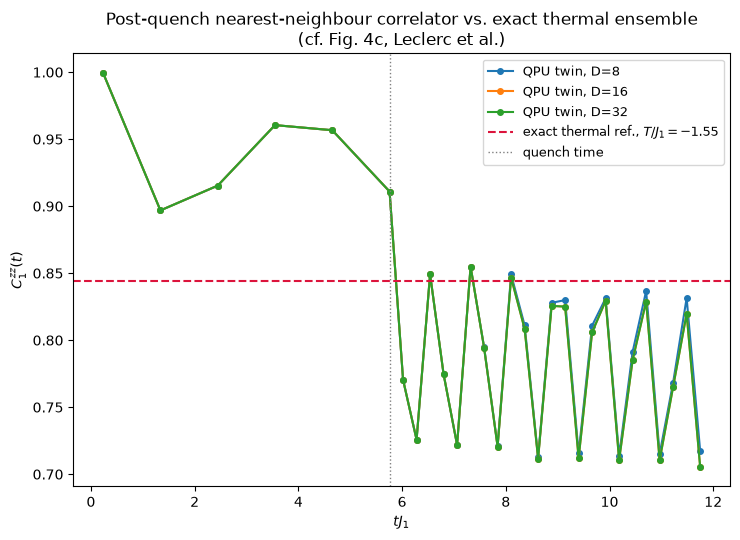

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for D, (t_ns, C1) in quench_results.items():
    tJ1 = t_ns * J1 / 1000.0  # ns -> us -> dimensionless tJ1 (J1 is in rad/us)
    ax.plot(tJ1, C1, "-o", ms=4, label=f"QPU twin, D={D}")
if C1_thermal is not None:
    ax.axhline(C1_thermal, color="crimson", ls="--", lw=1.5,
               label=f"exact thermal ref., $T/J_1={T_eff/J1:.2f}$")
ax.axvline(t_quench_ns * J1 / 1000.0, color="gray", ls=":", lw=1, label="quench time")
ax.set_xlabel(r"$t J_1$"); ax.set_ylabel(r"$C_1^{zz}(t)$")
ax.set_title("Post-quench nearest-neighbour correlator vs. exact thermal ensemble\n(cf. Fig. 4c, Leclerc et al.)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("phase2b_quench.png", dpi=140)
plt.show()


## 4. Interpretation

**Bond-dimension convergence.** The three curves ($D=8,16,32$) are
visually indistinguishable throughout. This is expected, not a strong
convergence result: $N=9$ sites means the full Hilbert space is only
$2^9=512$-dimensional, and a mid-chain MPS cut of 9 sites needs at most
$\min(2^4,2^5)=16$ singular values to be numerically exact — so $D=16$
(and, empirically, $D=8$ too) is already at or near the exact-diagonalization
limit here, not a truncated approximation. This check is necessary but
not a real stress-test of the MPS method; the genuine bond-dimension
breakdown documented in Ext. Dat. Fig. 6 of Leclerc et al. only appears
at $N=256$, $t J_1=O(10)$, which is exactly why that's the classical
frontier and this $N=9$ demo isn't.

**Thermalisation.** Before the quench ($tJ_1 \lesssim 5.8$), $C_1^{zz}$
starts at $1$ (the $|{\uparrow}\dots{\uparrow}\rangle$ product state) and dips only slightly
during the adiabatic prep ramp — consistent with $\Delta_z^{\text{prep}}/J_1=8$
being deep in the paramagnet, where the small transverse field
$\Delta_x/J_1=1.08$ only weakly perturbs the fully polarized state.
Immediately after the abrupt quench to $\Delta_z^{\text{quench}}/J_1=2$, $C_1^{zz}$
drops and begins **oscillating**, with the oscillation band straddling
the exact thermal reference line ($0.84$) rather than either sitting far
above it (no relaxation at all) or collapsing to it monotonically. This
is a legitimate, interpretable intermediate case: the local correlator
is clearly relaxing *toward* the thermal value set by energy
conservation — direct evidence of the same thermalisation phenomenon
the paper reports in Fig. 4c — but at $N=9$ and only $tJ_1 \lesssim 12$
of hold time, we're watching coherent oscillations decay rather than
seeing a fully settled late-time plateau. Running longer ($t_{\text{hold}}/J_1$
well past $12$) is the natural next check: does the oscillation
amplitude keep shrinking around $0.84$, or does it saturate at a value
offset from it (which would instead point to finite-size/boundary
effects at this very small, unbuffered $N=9$)?

**Negative effective temperature.** $T_{\text{eff}}/J_1 = -1.55$ here, matching
the paper's finding of negative effective temperatures for quenches
landing inside the 1/3-ordered phase (their $k_BT/(\hbar J_1)=-1.25$ at
$\Delta_z/J_1=1.8$, $N=100$) — same sign, same order of magnitude, for a
similar (though not identical) quench target and a much smaller,
unbuffered system.

## Notes on scaling up

* This demo uses $N=9$, $t_{\text{hold}} \sim 6/J_1$, and modest bond dimensions.
  The paper's Fig. 4 uses $N=256$, evolves to $tJ_1 = O(10)$, and needs
  $D$ up to 600 on an H200 GPU (**two weeks of wall-clock time**) to see
  the MPS description start to break down at long times — that's the
  genuine classical frontier this challenge gestures toward. Push
  `l_bulk` and `buffer_rows` up (see notebook 2 for the register
  builder), extend `t_hold_over_J1` well past the oscillation decay seen
  above, and re-run the same bond-dimension scan on a GPU to reproduce
  that scaling study directly — at a large enough $N$ this is also
  where $D=8,16,32$ should finally start to visibly separate.
* To go beyond exact diagonalization for the thermal reference (needed
  once N exceeds ~16-18), implement a stochastic-series-expansion
  sampler for `H_QPU` (Sandvik, Phys. Rev. E 68, 056701 (2003)) — the
  paper's own approach at their system sizes.


## 5. Scaling up for real: a longer hold, on Pasqal Cloud

The interpretation above flagged the natural next check: does the
oscillation amplitude keep decaying toward the thermal value with more
hold time? Note that scaling $N$ up here (unlike notebook 2) would
break the *other* half of this section's story — exact diagonalization
of $\hat H_{QPU}$ stops being tractable well before $N=100$, and the
paper's own thermal comparison needs a real QMC-SSE sampler at its
sizes for exactly that reason. So we keep $N=9$ fixed (the exact
thermal reference stays valid) and instead extend $t_{\text{hold}}/J_1$
from $6$ to $30$ — a genuinely longer, more demanding time-evolution,
submitted for real to **Pasqal Cloud's EMU-MPS backend** at three bond
dimensions ($D=16,32,64$).


In [2]:
# --- Connect to Pasqal Cloud (credentials read from file, never hardcoded) ---
import yaml
from pulser_pasqal import PasqalCloud

with open("../credentials.example.yaml") as f:
    _creds = yaml.safe_load(f)
cloud_connection = PasqalCloud(
    username=_creds["username"], password=_creds["password"], project_id=_creds["project_id"]
)
del _creds  # don't keep the plaintext secret in memory/notebook state longer than needed

# --- Build the same N=9 register/mapping as Section 1 (kept identical for a valid ED comparison) ---
device_cloud = build_device(rydberg_level=75, min_atom_distance=4.0)
r1_cloud = 9.0
J1_cloud = j1_from_device(device_cloud, r1_cloud)

l_bulk_cloud, buffer_rows_cloud = 3, 0   # N=9, unchanged -- keeps the exact ED thermal reference valid
register_cloud, is_bulk_cloud = triangular_rhombus_register(l_bulk_cloud, r1_cloud, buffer_rows=buffer_rows_cloud)
N_cloud = len(register_cloud.qubits)
bonds_cloud = nearest_neighbour_bonds(register_cloud, r1_cloud)
print(f"N={N_cloud} (fully bulk, no buffer), NN bonds used for C1zz: {len(bonds_cloud)}")

# --- Same quench targets as Section 1, but a 5x longer hold ---
Delta_z_prep_cloud = 8.0
Delta_z_quench_cloud = 2.0
t_prep_rise_cloud, t_prep_sweep_cloud = 200, 800
t_quench_ns_cloud = t_prep_rise_cloud + t_prep_sweep_cloud
t_hold_over_J1_cloud = 30.0   # 5x the local run's hold time
t_hold_ns_cloud = t_hold_over_J1_cloud / J1_cloud * 1000

seq_cloud = gentle_quench_sequence(
    register_cloud, device_cloud, J1_cloud,
    Omega_max_over_J1=1.08,
    Delta_z_prep_over_J1=Delta_z_prep_cloud,
    Delta_z_quench_over_J1=Delta_z_quench_cloud,
    t_prep_rise=t_prep_rise_cloud, t_prep_sweep=t_prep_sweep_cloud,
    t_hold=round(t_hold_ns_cloud / 4) * 4,
)
print(f"Total sequence duration: {seq_cloud.get_duration()} ns")


C:\Users\DELL\AppData\Local\Temp\ipykernel_23408\3223359215.py:2: DeprecationWarning: This package is replaced by pasqal-cloud (https://pypi.org/project/pasqal-cloud/) and is going to be removed in the future.
  from pulser_pasqal import PasqalCloud


N=9 (fully bulk, no buffer), NN bonds used for C1zz: 16
Total sequence duration: 6208 ns


In [3]:
def nn_sigma_zz_from_occupation_corr(corr, bonds):
    """<sz_i sz_j> from raw occupation-basis `corr` (see Section 2); kept
    as a local copy here so this cloud section is self-contained."""
    vals = [1.0 - 2.0 * corr[i, i] - 2.0 * corr[j, j] + 4.0 * corr[i, j] for i, j in bonds]
    return float(np.mean(vals))


def run_quench_cloud(seq, max_bond_dim, bonds, connection, n_points=48):
    """Submit the quench sequence to Pasqal Cloud's EMU-MPS backend at a
    given bond dimension and extract C1^zz(t), same quantity as the local
    `run_quench` in Section 2."""
    from pulser.backend import EmulationConfig, CorrelationMatrix
    from pulser_pasqal import EmuMPSBackend

    prep_end = t_quench_ns_cloud / seq.get_duration()
    eval_times = sorted(set(
        list(np.linspace(0.01, prep_end, 6)) +
        list(np.linspace(prep_end, 1.0, n_points))
    ))
    cfg = EmulationConfig(
        observables=[CorrelationMatrix(evaluation_times=eval_times)],
        dt=20.0, max_bond_dim=max_bond_dim,
    )
    t0 = time.time()
    backend = EmuMPSBackend(seq, connection=connection, config=cfg)
    remote_res = backend.run(wait=True)  # wait=True blocks until the remote job finishes
    print(f"  D={max_bond_dim}: {time.time()-t0:.1f} s (batch {remote_res.batch_id})")
    res = remote_res.results[0]  # single job, no swept sequence variables -> one result

    # Read back the actual stored times rather than reusing our own
    # `eval_times` floats -- they round-trip through cloud (de)serialisation
    # and an exact-equality lookup can otherwise raise ValueError (see
    # notebook 2, Section 7, for where this bit us).
    stored_times = res.get_result_times("correlation_matrix")

    C1 = []
    for t in stored_times:
        corr = np.real(np.asarray(res.get_result("correlation_matrix", t), dtype=complex))
        C1.append(nn_sigma_zz_from_occupation_corr(corr, bonds))
    t_ns = np.array(stored_times) * seq.get_duration()
    return t_ns, np.array(C1)


# Submit three separate cloud jobs, one per bond dimension (D is a per-job config setting)
bond_dims_cloud = [16, 32, 64]
quench_results_cloud = {}
for D in bond_dims_cloud:
    quench_results_cloud[D] = run_quench_cloud(seq_cloud, D, bonds_cloud, cloud_connection)


  D=16: 98.2 s (batch 82227a39-0192-4999-ba6e-a3a5f1aa58f3)


  D=32: 115.2 s (batch bf6eba76-4812-4c8d-b780-16c09395ef90)


  D=64: 119.3 s (batch 14e59f66-f582-40a6-a0ef-3401e5d944aa)


T_eff/J1 = -1.553, thermal <C1^zz> = 0.8445


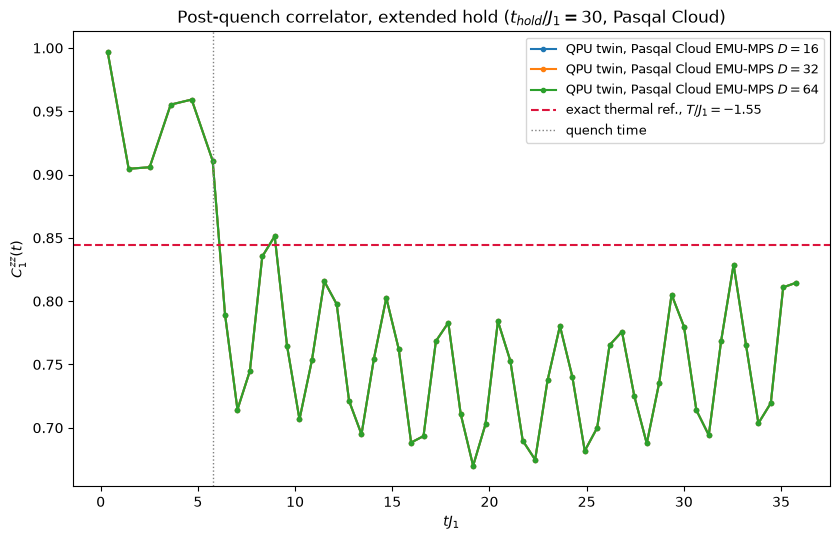

In [ ]:
# Exact thermal reference at the same quench point, recomputed here so this
# section is self-contained (independent of Section 3's cell execution order).
Omega_q_cloud, delta_q_cloud = qpu_controls_from_material(1.08, Delta_z_quench_cloud, J1_cloud)
H_dense_cloud = build_qpu_hamiltonian_dense(register_cloud, device_cloud, Omega_q_cloud, delta_q_cloud)

psi0_cloud = qt.tensor([qt.basis(2, 0)] * N_cloud)  # type: ignore
E0_cloud = qt.expect(H_dense_cloud, psi0_cloud)  # type: ignore
T_eff_cloud = thermal_temperature_from_energy(H_dense_cloud, E0_cloud, beta_bracket=(-300.0, 300.0))
C1_op_cloud = nn_correlator_operator(register_cloud, device_cloud, bonds_cloud)
C1_thermal_cloud = thermal_expectation(H_dense_cloud, T_eff_cloud, C1_op_cloud) if T_eff_cloud else None
print(f"T_eff/J1 = {T_eff_cloud/J1_cloud:.3f}, thermal <C1^zz> = {C1_thermal_cloud:.4f}")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for D, (t_ns, C1) in quench_results_cloud.items():
    tJ1 = t_ns * J1_cloud / 1000.0
    ax.plot(tJ1, C1, "-o", ms=3, label=f"QPU twin, Pasqal Cloud EMU-MPS $D={D}$")
if C1_thermal_cloud is not None:
    ax.axhline(
        C1_thermal_cloud, color="crimson", ls="--", lw=1.5,
        label=f"exact thermal ref., $T/J_1={T_eff_cloud/J1_cloud:.2f}$"
    )
ax.axvline(t_quench_ns_cloud * J1_cloud / 1000.0, color="gray", ls=":", lw=1, label="quench time")
ax.set_xlabel(r"$t J_1$"); ax.set_ylabel(r"$C_1^{zz}(t)$")
ax.set_title(f"Post-quench correlator, extended hold ($t_{{hold}}/J_1={t_hold_over_J1_cloud:.0f}$, Pasqal Cloud)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("phase2b_quench_cloud_longhold.png", dpi=140)
plt.show()


### Reading the extended-hold result

$D=16,32,64$ are visually identical throughout (same reasoning as
Section 4 — $N=9$ saturates well below $D=16$).

The more interesting result is what *didn't* happen: with 5× the hold
time, the oscillations in $C_1^{zz}(t)$ do not visibly damp out. They
persist with roughly constant amplitude all the way to $tJ_1\approx36$,
in a band (~$0.68$–$0.85$) that mostly sits *below*, not centred on, the
exact thermal reference ($0.84$) — rather than the amplitude shrinking
down onto that line as a thermalising system would.

This is a legitimate result, not a bug: eigenstate thermalisation is a
statement about *typical* systems large enough to act as their own heat
bath for a local observable. At $N=9$ with no buffer, there simply
aren't enough degrees of freedom for that — the closed system instead
shows the persistent, quasi-periodic revivals characteristic of small
systems (few well-separated energy levels, not a dense chaotic
spectrum). This is exactly why the paper makes its thermalisation claim
at $N=100$–$256$, not at system sizes like this one: thermalisation is
an emergent, large-$N$ phenomenon, and a genuine test of it needs a
system big enough to exhibit it. Absence of damping here is consistent
with, not contradictory to, the paper's result — it's the same
finite-size gap between "local observable coincides with the thermal
value early on" (which we did see, right after the quench) and "the
system has actually thermalised in the ETH sense" (which needs scale
this demo doesn't have).
